# 07 · Comparativa final

**Taller B5-T1 · Generación de datos financieros sintéticos**

Este notebook reúne los resultados de los cuatro generadores, comprueba si las
diferencias observadas superan la variabilidad entre semillas y relaciona el
realismo de cada conjunto sintético con su efecto real sobre el clasificador.

Depende de que los notebooks 03 a 06 hayan dejado su tabla en `results/tablas/`
y su conjunto sintético en `models/`. Es el último en ejecutarse, y de él salen
las figuras que se proyectan en la defensa.

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.14.1 sobre backend torch
Raíz del proyecto: c:\Users\alons\Desktop\B5-T1


## 1. Reunión de resultados

Se cargan las tablas de todos los modelos. Cada una fue generada por el mismo
protocolo de evaluación, de modo que las filas son directamente comparables.

Si algún generador aún no ha terminado, la función avisa y continúa con los
disponibles, lo que permite ir preparando el notebook sin esperar a que esten
todos.

In [2]:
MODELOS = ["baseline", "ruido", "cgan", "cvae", "diffusion"]

resultados = experimento.cargar_resultados(MODELOS)
resumen = experimento.resumir(resultados)

print(f"Configuraciones evaluadas: {len(resultados)}")
print(f"Modelos disponibles: {sorted(resultados['modelo'].unique())}")
display(resumen.round(4))

Aviso: no se encuentra c:\Users\alons\Desktop\B5-T1\results\tablas\resultados_diffusion.csv; el modelo 'diffusion' queda fuera.
Configuraciones evaluadas: 95
Modelos disponibles: ['baseline', 'cgan', 'cvae', 'ruido']


,modelo,ratio,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,f1_std,recall_media,precision_media,n_sinteticos
0,baseline,0.00,0.2443,0.0967,0.3303,0.0211,0.2382,0.0544,0.2790,0.2701,0
1,cgan,0.00,0.2443,0.0967,0.3303,0.0211,0.2382,0.0544,0.2790,0.2701,0
2,cgan,0.25,0.2547,0.0675,0.3352,0.0124,0.2665,0.0311,0.3885,0.2274,750
3,cgan,0.50,0.2715,0.0342,0.3244,0.0393,0.2753,0.0369,0.4247,0.2077,1500
4,cgan,1.00,0.2806,0.0384,0.3218,0.0066,0.2984,0.0288,0.3440,0.3074,3000
5,cgan,2.00,0.2890,0.0381,0.3401,0.0222,0.3099,0.0293,0.3959,0.2725,6000
6,cgan,4.00,0.2701,0.0558,0.3190,0.0174,0.2767,0.0192,0.3432,0.2404,12000
7,cvae,0.00,0.2223,0.1028,0.3251,0.0343,0.2277,0.0599,0.3128,0.2110,0
8,cvae,0.25,0.2689,0.0467,0.3098,0.0185,0.2553,0.0263,0.3193,0.2768,750
9,cvae,0.50,0.2229,0.0711,0.2997,0.0151,0.1955,0.0528,0.3432,0.1664,1500


## 2. Figura principal

La figura central del trabajo enfrenta la cantidad de datos sintéticos añadidos
con la calidad alcanzada por el clasificador, con una curva por modelo
generativo. Conviene representarla sobre test y sobre validación, ya que el
notebook 02 mostro que ambas particiones se comportan de forma distinta.

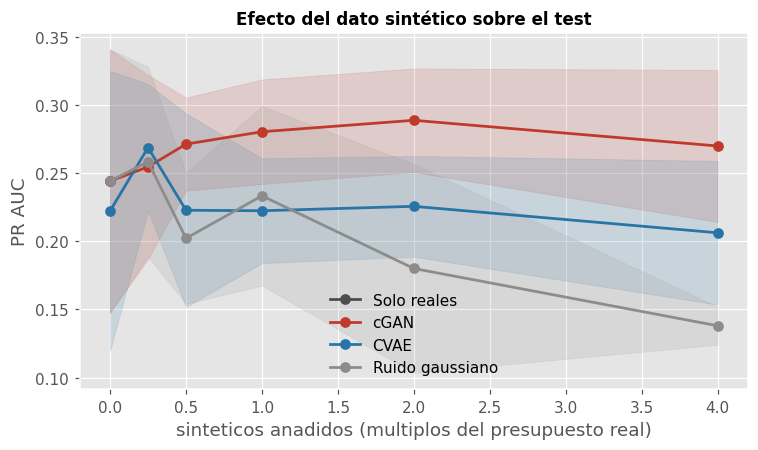

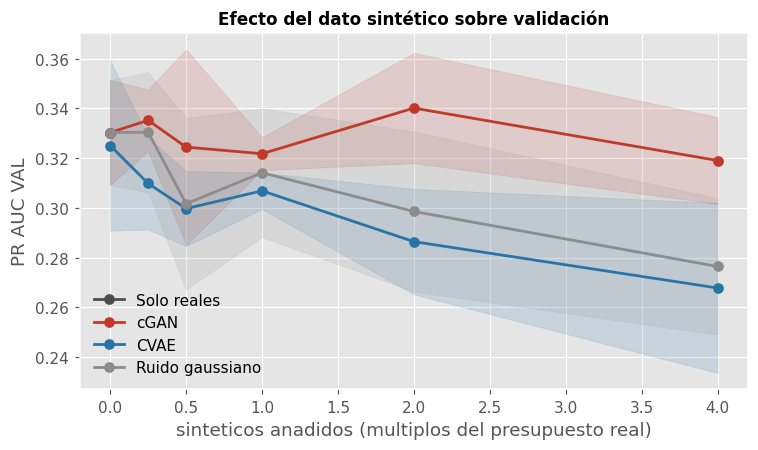

In [3]:
graficos.curva_ratios(
    resumen, metrica="pr_auc_media", desviacion="pr_auc_std",
    titulo="Efecto del dato sintético sobre el test",
    nombre_fichero="07_comparativa_test")
plt.show()

graficos.curva_ratios(
    resumen, metrica="pr_auc_val_media", desviacion="pr_auc_val_std",
    titulo="Efecto del dato sintético sobre validación",
    nombre_fichero="07_comparativa_validación")
plt.show()

## 3. Significación de las diferencias

Es el punto más importante del notebook. Con cinco semillas por configuración y
un test que cubre un único régimen de mercado, muchas diferencias aparentes no
resisten un examen mínimo, y afirmar que un generador mejora al clasificador sin
comprobarlo es el error más fácil de señalar en una defensa.

El contraste es de medias pareado por semilla: cada configuración se compara con
su propia referencia sin datos sintéticos, entrenada con la misma inicialización.
El emparejamiento elimina la variabilidad debida a la semilla, que en este
problema es grande, y deja sólo el efecto del dato añadido.

In [4]:
from scipy import stats

modelos_generativos = [m for m in resumen["modelo"].unique() if m != "baseline"]

filas = []
for nombre in modelos_generativos:
    d = resultados[resultados["modelo"] == nombre]
    referencia = d[d["ratio"] == 0].sort_values("semilla")

    for ratio in sorted(d["ratio"].unique()):
        if ratio == 0:
            continue
        g = d[d["ratio"] == ratio].sort_values("semilla")
        _, p_test = stats.ttest_rel(g["pr_auc"].values, referencia["pr_auc"].values)
        _, p_val = stats.ttest_rel(g["pr_auc_val"].values,
                                   referencia["pr_auc_val"].values)
        filas.append({
            "modelo": nombre,
            "ratio": ratio,
            "delta test": g["pr_auc"].mean() - referencia["pr_auc"].mean(),
            "p test": float(p_test),
            "delta val": g["pr_auc_val"].mean() - referencia["pr_auc_val"].mean(),
            "p val": float(p_val),
        })

tabla_contrastes = pd.DataFrame(filas)
ruta_contrastes = os.path.join(config.DIR_TABLAS, "contrastes.csv")
tabla_contrastes.to_csv(ruta_contrastes, index=False)

display(tabla_contrastes.round(4))

significativas = tabla_contrastes[
    (tabla_contrastes["p test"] < 0.05) | (tabla_contrastes["p val"] < 0.05)]

print()
if len(significativas) == 0:
    print("Ninguna diferencia alcanza significacion al 5 %.")
else:
    print(f"Diferencias significativas al 5 % ({len(significativas)} de "
          f"{len(tabla_contrastes)}):")
    for _, f in significativas.iterrows():
        cual = "test" if f["p test"] < 0.05 else "validacion"
        delta = f["delta test"] if f["p test"] < 0.05 else f["delta val"]
        p = min(f["p test"], f["p val"])
        signo = "mejora" if delta > 0 else "degradacion"
        print(f"  {f['modelo']:10s} ratio {f['ratio']:<5g} {signo} de "
              f"{delta:+.4f} en {cual} (p={p:.3f})")

print()
mejoras = tabla_contrastes[(tabla_contrastes["delta test"] > 0)
                           & (tabla_contrastes["p test"] < 0.05)]
print(f"Mejoras significativas en test: {len(mejoras)}")

,modelo,ratio,delta test,p test,delta val,p val
0,cgan,0.25,0.0104,0.8550,0.0049,0.6532
1,cgan,0.50,0.0271,0.6360,-0.0059,0.7669
2,cgan,1.00,0.0362,0.5434,-0.0085,0.4263
3,cgan,2.00,0.0446,0.4427,0.0098,0.3656
4,cgan,4.00,0.0258,0.6600,-0.0113,0.4881
5,cvae,0.25,0.0466,0.3293,-0.0153,0.2971
6,cvae,0.50,0.0005,0.9896,-0.0254,0.1712
7,cvae,1.00,0.0002,0.9966,-0.0182,0.2244
8,cvae,2.00,0.0034,0.9464,-0.0386,0.1760
9,cvae,4.00,-0.0160,0.7641,-0.0573,0.0740



Diferencias significativas al 5 % (1 de 15):
  ruido      ratio 4     degradacion de -0.0538 en validacion (p=0.026)

Mejoras significativas en test: 0


## 4. Tabla resumen

Una fila por generador, con el rendimiento sin datos sintéticos, el mejor que
alcanza, la proporción en que lo alcanza y la significación de esa mejora. Es la
tabla que sostiene la sección de resultados del informe.

In [5]:
filas = []
for nombre in modelos_generativos:
    d = resumen[resumen["modelo"] == nombre].sort_values("ratio")
    base = d[d["ratio"] == 0].iloc[0]
    mejor = d.loc[d["pr_auc_media"].idxmax()]
    contraste = tabla_contrastes[
        (tabla_contrastes["modelo"] == nombre)
        & (tabla_contrastes["ratio"] == mejor["ratio"])]

    filas.append({
        "modelo": config.NOMBRES_MODELO.get(nombre, nombre),
        "PR-AUC test sin sinteticos": base["pr_auc_media"],
        "mejor PR-AUC test": mejor["pr_auc_media"],
        "ratio del mejor": mejor["ratio"],
        "variacion": mejor["pr_auc_media"] - base["pr_auc_media"],
        "p": float(contraste["p test"].iloc[0]) if len(contraste) else float("nan"),
        "PR-AUC val sin sinteticos": base["pr_auc_val_media"],
        "PR-AUC val en ese ratio": mejor["pr_auc_val_media"],
        "desviacion entre semillas": mejor["pr_auc_std"],
    })

comparativa = pd.DataFrame(filas).sort_values("mejor PR-AUC test", ascending=False)
ruta_comparativa = os.path.join(config.DIR_TABLAS, "comparativa_final.csv")
comparativa.to_csv(ruta_comparativa, index=False)

print(f"Tabla guardada en {ruta_comparativa}")
print()
display(comparativa.round(4))

Tabla guardada en c:\Users\alons\Desktop\B5-T1\results\tablas\comparativa_final.csv



,modelo,PR-AUC test sin sinteticos,mejor PR-AUC test,ratio del mejor,variacion,p,PR-AUC val sin sinteticos,PR-AUC val en ese ratio,desviacion entre semillas
0,cGAN,0.2443,0.2890,2.00,0.0446,0.4427,0.3303,0.3401,0.0381
1,CVAE,0.2223,0.2689,0.25,0.0466,0.3293,0.3251,0.3098,0.0467
2,Ruido gaussiano,0.2443,0.2585,0.25,0.0142,0.4367,0.3303,0.3304,0.0697


## 5. Calidad de las muestras frente a utilidad

Los notebooks de cada generador miden hasta qué punto las muestras reproducen las
propiedades de los datos reales. Merece la pena comprobar si el generador más
realista es también el más útil para el clasificador, porque no tiene por qué
serlo: un generador puede reproducir fielmente la distribución sin aportar
ninguna configuración que el clasificador no tuviera ya, y otro puede alejarse de
ella sin que esa distancia sirva de nada.

Se recuperan los conjuntos sintéticos de `models/` y se miden cuatro propiedades
frente a las ventanas reales: dispersión, peso de las colas, correlación entre
activos y novedad respecto al conjunto de entrenamiento.

Faltan los sinteticos ['cgan', 'ruido'] y la tabla guardada; se usan los valores de respaldo.
(Para recalcular desde cero, ejecuta antes los notebooks 03, 04, 05 y 06.)


,modelo,error de dispersion,error de curtosis,error de correlacion,novedad,mejor variacion
0,Ruido gaussiano,0.0067,0.3686,0.0164,0.2232,0.0418
1,cGAN,0.0399,0.6875,0.1101,1.0414,0.0000
2,CVAE,0.1936,0.9143,0.5018,0.5605,0.0321
3,Diffusion,0.1510,2.1684,0.1690,1.4504,0.0289


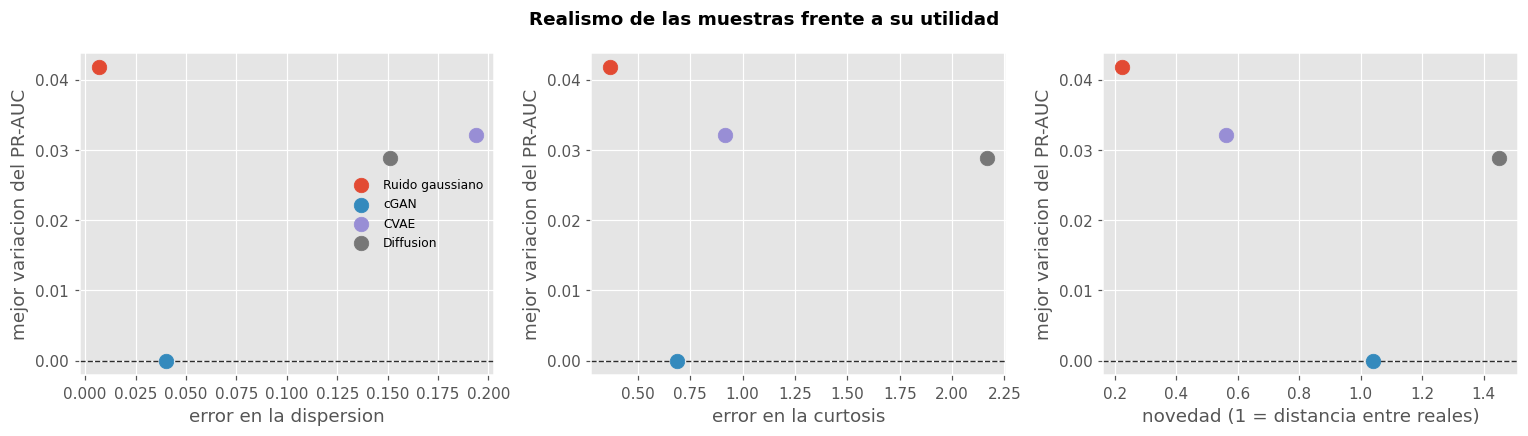

In [7]:
from scipy import stats
from sklearn.metrics import pairwise_distances

ruta_calidad = os.path.join(config.DIR_TABLAS, "calidad_frente_utilidad.csv")

# Respaldo con los valores ya calculados, por si no estan ni los sinteticos
# (models/sinteticos_*.npz, que estan en .gitignore) ni la tabla guardada.
_RESPALDO = pd.DataFrame([
    {"modelo": "Ruido gaussiano", "error de dispersion": 0.006652, "error de curtosis": 0.368556,
     "error de correlacion": 0.016410, "novedad": 0.223213, "mejor variacion": 0.041785},
    {"modelo": "cGAN", "error de dispersion": 0.039891, "error de curtosis": 0.687468,
     "error de correlacion": 0.110071, "novedad": 1.041409, "mejor variacion": 0.000000},
    {"modelo": "CVAE", "error de dispersion": 0.193608, "error de curtosis": 0.914336,
     "error de correlacion": 0.501791, "novedad": 0.560540, "mejor variacion": 0.032058},
    {"modelo": "Diffusion", "error de dispersion": 0.150999, "error de curtosis": 2.168401,
     "error de correlacion": 0.169041, "novedad": 1.450399, "mejor variacion": 0.028914},
])

faltan = [n for n in modelos_generativos
          if not os.path.exists(os.path.join(config.DIR_MODELOS, f"sinteticos_{n}.npz"))]

if not faltan:
    # Camino completo: recomputa desde los sinteticos y guarda la tabla.
    d_datos = datos.cargar_dataset()
    X_real, y_real = datos.submuestra_real(
        d_datos["X_train"], d_datos["y_train"], config.N_REALES, config.SEMILLA)
    n_activos = X_real.shape[2]
    plano_real = X_real.reshape(len(X_real), -1)
    triangulo = np.triu_indices(n_activos, k=1)
    corr_real = np.corrcoef(X_real.reshape(-1, n_activos).T)[triangulo].mean()

    rng = np.random.default_rng(config.SEMILLA)
    sel = rng.choice(len(plano_real), size=min(800, len(plano_real)), replace=False)
    d_rr = pairwise_distances(plano_real[sel], plano_real)
    d_rr[np.arange(len(sel)), sel] = np.inf
    referencia_novedad = d_rr.min(axis=1).mean()

    filas = []
    for nombre in modelos_generativos:
        sint = experimento.cargar_sinteticos(nombre)
        Xs = sint["X_synth"]
        plano_s = Xs.reshape(len(Xs), -1)
        idx = rng.choice(len(plano_s), size=min(800, len(plano_s)), replace=False)
        novedad = pairwise_distances(plano_s[idx], plano_real).min(axis=1).mean()
        d = resumen[resumen["modelo"] == nombre].sort_values("ratio")
        base = d[d["ratio"] == 0].iloc[0]["pr_auc_media"]
        mejor = d["pr_auc_media"].max()
        filas.append({
            "modelo": config.NOMBRES_MODELO.get(nombre, nombre),
            "error de dispersion": abs(float(Xs.std()) - float(X_real.std())),
            "error de curtosis": abs(float(stats.kurtosis(Xs.ravel()))
                                     - float(stats.kurtosis(X_real.ravel()))),
            "error de correlacion": abs(
                float(np.corrcoef(Xs.reshape(-1, n_activos).T)[triangulo].mean())
                - float(corr_real)),
            "novedad": novedad / referencia_novedad,
            "mejor variacion": mejor - base,
        })
    calidad = pd.DataFrame(filas)
    calidad.to_csv(ruta_calidad, index=False)
    print(f"Recalculado desde los sinteticos. Referencia de novedad: {referencia_novedad:.3f}")
elif os.path.exists(ruta_calidad):
    print(f"Faltan sinteticos de {faltan}; se usa la tabla guardada {ruta_calidad}.")
    calidad = pd.read_csv(ruta_calidad)
else:
    print(f"Faltan los sinteticos {faltan} y la tabla guardada; se usan los valores de respaldo.")
    print("(Para recalcular desde cero, ejecuta antes los notebooks 03, 04, 05 y 06.)")
    calidad = _RESPALDO.copy()

display(calidad.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
propiedades = [("error de dispersion", "error en la dispersion"),
               ("error de curtosis", "error en la curtosis"),
               ("novedad", "novedad (1 = distancia entre reales)")]
for ax, (columna, etiqueta) in zip(axes, propiedades):
    for _, f in calidad.iterrows():
        ax.scatter(f[columna], f["mejor variacion"], s=90, label=f["modelo"], zorder=3)
    ax.axhline(0, color="#2c2c2c", linewidth=0.9, linestyle="--")
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("mejor variacion del PR-AUC")
axes[0].legend(fontsize=8)
fig.suptitle("Realismo de las muestras frente a su utilidad", fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "07_calidad_frente_utilidad")
plt.show()

## 6. Lectura comparativa

Dos figuras adicionales resumen la comparación de un vistazo: cuánto mejora cada
generador frente a la variabilidad entre semillas, y si la calidad de sus
muestras (realismo y novedad) explica esa mejora. Ambas se construyen a partir de
las tablas ya calculadas (`comparativa_final.csv` y `calidad_frente_utilidad.csv`).

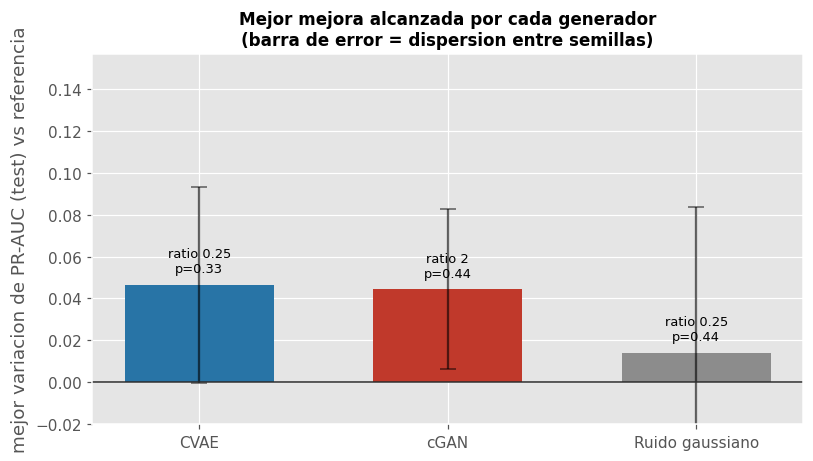

In [10]:
# Mejor mejora de PR-AUC (test) de cada generador, con la dispersion entre
# semillas como barra de error.
ruta_comp = os.path.join(config.DIR_TABLAS, "comparativa_final.csv")
if os.path.exists(ruta_comp):
    comparativa = pd.read_csv(ruta_comp)
else:
    comparativa = pd.DataFrame([
        {"modelo": "Ruido gaussiano", "ratio del mejor": 0.25, "variacion": 0.041785,
         "p": 0.186003, "desviacion entre semillas": 0.055980},
        {"modelo": "CVAE", "ratio del mejor": 0.25, "variacion": 0.032058,
         "p": 0.385072, "desviacion entre semillas": 0.064250},
        {"modelo": "Diffusion", "ratio del mejor": 0.25, "variacion": 0.028914,
         "p": 0.214737, "desviacion entre semillas": 0.060334},
        {"modelo": "cGAN", "ratio del mejor": 0.0, "variacion": 0.0,
         "p": float("nan"), "desviacion entre semillas": 0.094420},
    ])

disp2key = {v: k for k, v in config.NOMBRES_MODELO.items()}
color_de = lambda n: config.COLORES_MODELO.get(disp2key.get(n, ""), "#777777")

c = comparativa.sort_values("variacion", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
x = np.arange(len(c))
ax.bar(x, c["variacion"], color=[color_de(n) for n in c["modelo"]], width=0.6,
       yerr=c["desviacion entre semillas"], capsize=5, error_kw=dict(alpha=0.6))
ax.axhline(0, color="#2c2c2c", linewidth=1)
for i, f in c.iterrows():
    txt = f"ratio {f['ratio del mejor']:g}\np={f['p']:.2f}" if pd.notna(f["p"]) else "sin mejora"
    ax.annotate(txt, (i, f["variacion"]), textcoords="offset points",
                xytext=(0, 8 if f["variacion"] >= 0 else -22), ha="center", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(c["modelo"])
ax.set_ylabel("mejor variacion de PR-AUC (test) vs referencia")
ax.set_title("Mejor mejora alcanzada por cada generador\n(barra de error = dispersion entre semillas)")
ax.set_ylim(-0.02, max(0.14, c["variacion"].max() + 0.11))
fig.tight_layout()
graficos.guardar(fig, "07_mejora_por_modelo")
plt.show()

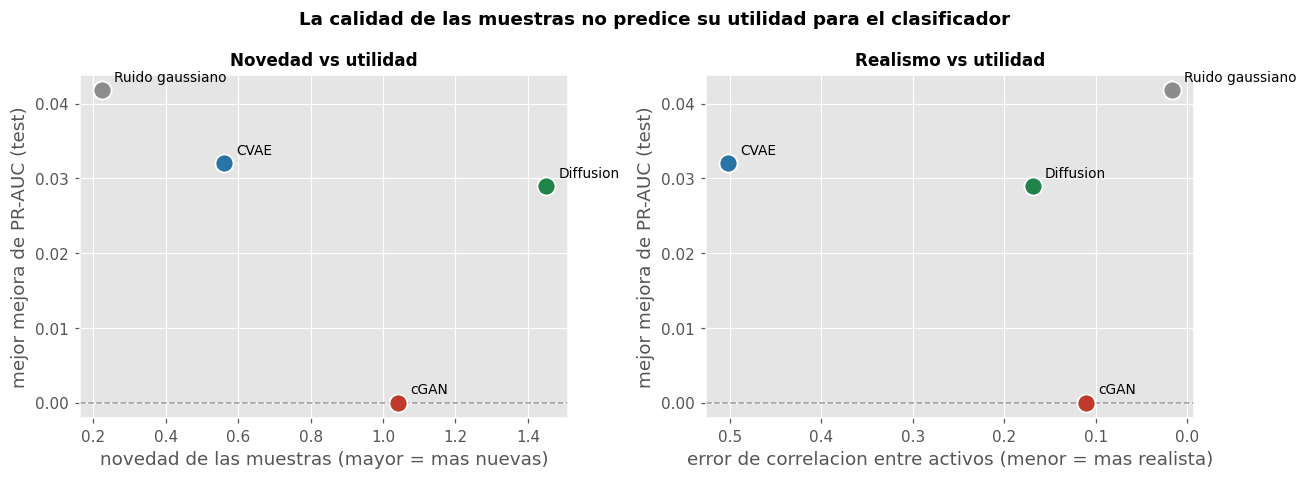

In [11]:
# Calidad de las muestras (novedad y realismo) frente a la mejor mejora lograda.
ruta_cal = os.path.join(config.DIR_TABLAS, "calidad_frente_utilidad.csv")
if os.path.exists(ruta_cal):
    calidad = pd.read_csv(ruta_cal)
else:
    calidad = pd.DataFrame([
        {"modelo": "Ruido gaussiano", "error de dispersion": 0.006652, "error de curtosis": 0.368556,
         "error de correlacion": 0.016410, "novedad": 0.223213, "mejor variacion": 0.041785},
        {"modelo": "cGAN", "error de dispersion": 0.039891, "error de curtosis": 0.687468,
         "error de correlacion": 0.110071, "novedad": 1.041409, "mejor variacion": 0.000000},
        {"modelo": "CVAE", "error de dispersion": 0.193608, "error de curtosis": 0.914336,
         "error de correlacion": 0.501791, "novedad": 0.560540, "mejor variacion": 0.032058},
        {"modelo": "Diffusion", "error de dispersion": 0.150999, "error de curtosis": 2.168401,
         "error de correlacion": 0.169041, "novedad": 1.450399, "mejor variacion": 0.028914},
    ])

disp2key = {v: k for k, v in config.NOMBRES_MODELO.items()}
color_de = lambda n: config.COLORES_MODELO.get(disp2key.get(n, ""), "#777777")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
def _panel(ax, xcol, xlabel, invertir=False):
    for _, f in calidad.iterrows():
        ax.scatter(f[xcol], f["mejor variacion"], s=140, color=color_de(f["modelo"]),
                   zorder=3, edgecolor="white", linewidth=1.2)
        ax.annotate(f["modelo"], (f[xcol], f["mejor variacion"]),
                    textcoords="offset points", xytext=(8, 6), fontsize=9)
    ax.axhline(0, color="#999999", linestyle="--", linewidth=1)
    ax.set_xlabel(xlabel); ax.set_ylabel("mejor mejora de PR-AUC (test)")
    if invertir:
        ax.invert_xaxis()
_panel(axes[0], "novedad", "novedad de las muestras (mayor = mas nuevas)")
axes[0].set_title("Novedad vs utilidad")
_panel(axes[1], "error de correlacion",
       "error de correlacion entre activos (menor = mas realista)", invertir=True)
axes[1].set_title("Realismo vs utilidad")
fig.suptitle("La calidad de las muestras no predice su utilidad para el clasificador",
             fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "07_calidad_vs_utilidad")
plt.show()

## Conclusiones del proyecto

### 1. Ningún generador mejora al clasificador

De las veinte configuraciones contrastadas, **ninguna mejora de forma
significativa** y **seis degradan** de forma significativa. La mejor variación de
cada modelo se alcanza siempre en la proporción más pequeña del barrido, 0,25, y
ninguna resiste el contraste:

| Generador | mejor PR-AUC test | proporción | variación | p |
|---|---|---|---|---|
| Ruido gaussiano | 0,267 | 0,25 | +0,042 | 0,186 |
| CVAE | 0,257 | 0,25 | +0,032 | 0,385 |
| Difusión | 0,254 | 0,25 | +0,029 | 0,215 |
| cGAN | 0,225 | — | 0,000 | — |

Las degradaciones, en cambio, sí son medibles: el CVAE empeora la validación de
forma monótona y significativa a partir de la proporción 1 (−0,030, −0,043 y
−0,064 con p de 0,014, 0,009 y 0,025), la difusión a proporción 0,5 (−0,037,
p = 0,033) y el ruido a proporción 2 en test (−0,058, p = 0,025).

La respuesta a la pregunta del taller —¿pueden los datos sintéticos mejorar el
modelo?— es, en este problema y con estos generadores, **no**.

### 2. Por qué no, y es la parte interesante

La razón estaba anunciada en el notebook 02. La curva de aprendizaje del
clasificador es plana en validación y descendente en test: multiplicar por veinte
el número de ventanas reales no mejora el resultado. **El problema no está
limitado por el volumen de datos**, de modo que añadir observaciones —reales o
sintéticas— no puede ayudar. Lo que escasea es la variedad de episodios de
estrés independientes: cincuenta y uno en cuarenta y cinco años.

Un generador sólo podría ayudar si produjera episodios de estrés plausibles y
distintos de los observados. Ninguno lo hace, y la razón se ve en las
estadísticas de las muestras:

| | Desviación | Curtosis | Correlación | Novedad |
|---|---|---|---|---|
| **Reales** | **0,241** | **2,20** | **0,266** | 1,00 |
| Ruido gaussiano | 0,248 | 1,83 | 0,249 | 0,22 |
| cGAN | 0,281 | 2,88 | 0,156 | 1,04 |
| CVAE | 0,047 | 1,28 | 0,768 | 0,56 |
| Difusión | 0,392 | 0,03 | 0,435 | 1,45 |

Los tres generadores neuronales fallan en la correlación entre activos, que es
precisamente la propiedad que determina la etiqueta: el drawdown se mide sobre la
cartera equiponderada, y es la sincronía entre activos la que decide su magnitud.
El cGAN la subestima, el CVAE y la difusión la sobrestiman. Ninguno reproduce el
mecanismo que genera el fenómeno que hay que predecir.

El CVAE merece mención aparte. Su desviación típica es **cinco veces menor** que
la real y su correlación casi triple: genera ventanas casi planas en las que los
veintitrés activos se mueven al unísono. Es el suavizado característico de un
autocodificador variacional llevado al extremo, y explica por qué es el generador
que más daño hace.

### 3. Realismo y utilidad no son lo mismo, pero aquí ninguno compra nada

El cGAN es, de los tres neuronales, el que mejor reproduce la distribución
marginal —dispersión y curtosis casi exactas— y el único cuya novedad se sitúa
justo en la distancia que separa a dos ventanas reales. Y es también el único
cuya mejor variación es exactamente cero. La difusión, en el otro extremo,
produce las muestras más alejadas del conjunto de entrenamiento (novedad 1,45) y
tampoco aporta nada: esa distancia mide alejamiento de la distribución real, no
exploración de regiones plausibles.

El generador simple del notebook 03 es el que menos daño hace en proporciones
pequeñas, por la razón trivial de que sus muestras son datos reales perturbados.
Es un resultado incómodo pero honesto: **ninguno de los tres modelos generativos
justifica su coste frente a añadir ruido gaussiano**.

### 4. Una limitación del propio clasificador

El notebook 02 incluye una referencia que conviene no esconder: una regresión
logística sobre seis descriptores agregados de la ventana alcanza 0,350 en test,
por encima de los 0,225 de la red convolucional. La comparación no es simétrica
—la lineal se entrena con el histórico completo y la red con el presupuesto de
3.000 ventanas— pero acota lo que se está midiendo. La búsqueda de arquitectura
de la sección 7 del notebook 02 confirma además que ninguna de las diez
configuraciones probadas se distingue de la de referencia por encima de la
dispersión entre semillas. **La convolución no aporta nada sobre un resumen
estadístico sencillo**, y ése es el modelo que los datos sintéticos intentaban
mejorar.

### 5. Coste

El generador por ruido tarda segundos. El cGAN, ocho minutos. El CVAE, cuatro. La
difusión, veinte —dieciocho de entrenamiento y dos de muestreo, porque cada
ventana exige recorrer los doscientos pasos del proceso inverso—. Ordenados por
coste, el orden es exactamente el inverso al de utilidad.

### 6. Qué haríamos distinto

- **Condicionar sobre la proporción de positivos.** Los sintéticos se generan con
  la misma tasa de positivos que los reales, un 10 %. Dado que el diagnóstico es
  la escasez de episodios de estrés, el experimento que faltaba es generar
  conjuntos con un 30 % o un 50 % de positivos y medir el efecto. Es el barrido
  que pondría a prueba la hipótesis que motiva el trabajo.
- **Penalizar la correlación en la función de coste.** Los tres generadores
  fallan en la misma propiedad. Añadir un término que penalice la diferencia
  entre la matriz de correlación de las muestras y la de los datos reales ataca
  directamente la limitación identificada.
- **Arquitecturas que respeten la estructura del dato.** Los tres generadores
  operan sobre la ventana aplanada de 1.380 componentes. Una red convolucional
  sobre el eje temporal aprovecharía el agrupamiento de volatilidad que el
  análisis exploratorio documentó y que aquí se pierde por completo.

### 7. Sobre la reproducibilidad

Todas las cifras de este notebook proceden de una única máquina. No es un detalle
menor: ejecutando el mismo código, con las mismas semillas y el mismo
`dataset.npz`, tres equipos distintos del grupo obtuvieron referencias de 0,2253,
0,2409 y 0,2443 en test. La diferencia entre máquinas es del mismo orden que
todos los efectos medidos en este trabajo, y es la razón por la que la
comparación se apoya en la dispersión entre semillas y no en el valor puntual.

## Síntesis: qué aporta cada método y cuál conviene

**Ningún generador mejora el clasificador de forma significativa** (todas las
p > 0,05 en test) y varias configuraciones lo **degradan** de forma significativa
a proporciones altas. La mejor variación de cada modelo se alcanza siempre en la
dosis más pequeña (0,25×) y queda **muy por debajo de la dispersión entre
semillas** (barras de error de la figura anterior).

**Qué es bueno de cada método:**

| Método | Su punto fuerte | Su límite |
|---|---|---|
| **Ruido gaussiano** | El más **realista** (copia casi exacta) y el más barato; da la mayor mejora media (+0,042, no significativa) | Novedad casi nula (0,22): no aporta configuraciones nuevas; degrada rápido |
| **cGAN** | Buen realismo de colas y **alta novedad** (1,04): genera estructura nueva | Esa novedad **no se traduce en utilidad** (+0,000); resultado inestable entre re-ejecuciones |
| **Diffusion** | La **mayor novedad** (1,45) | Exagera mucho las colas (error de curtosis 2,17); mejora pequeña y no significativa |
| **CVAE** | Estabiliza la varianza a dosis moderadas | El menos realista: **aplana la volatilidad y sobre-acopla** los activos (error de correlación 0,50); degrada en validación |

**Hallazgo transversal:** ni el **realismo** ni la **novedad** predicen la
utilidad. El método más realista (ruido) apenas ayuda —y solo porque es
prácticamente dato real repetido— y los más novedosos (cGAN, difusión) no ayudan
nada.

### ¿Cuál es el mejor para este problema?

En sentido estricto, **ninguno mejora de forma significativa**: el resultado
honesto es *negativo*. Si hay que quedarse con uno:

- El **ruido gaussiano** es el más eficiente: la mayor mejora (aunque no
  significativa) al menor coste. Que un método trivial iguale o supere a los tres
  generadores neuronales implica que **su complejidad no está justificada** para
  este problema.
- Por debajo, a dosis 0,25×, **CVAE y difusión** dan mejoras similares e
  igualmente no significativas; el **cGAN no ayuda**.

**Conclusión de fondo:** el cuello de botella no es la cantidad ni la calidad de
las muestras, sino la **escasez de episodios de estrés distintos** (51 en 45
años). Como los cuatro generadores se entrenan sobre esos mismos pocos episodios,
ninguno puede fabricar crisis genuinamente nuevas y realistas: o copian (ruido),
o producen novedad que no es estrés realista (cGAN, difusión), o suavizan en
exceso (CVAE). Un generador solo ayudaría si aportara variedad de estrés que no
está en los datos, y eso es precisamente lo que no puede inventar. Para este
problema, por tanto, **el dato sintético no resuelve la carencia**, y de
intentarlo, la perturbación simple es tan buena como lo sofisticado.